In [1]:
import numpy as numpy
import pandas as pd

In [2]:
data= pd.read_csv('diabetes.csv')
data

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [4]:
data.duplicated().sum()

np.int64(3854)

In [5]:
data=data.drop_duplicates()

In [6]:
data.duplicated().sum()

np.int64(0)

In [7]:
data.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000
mean,41.794326,0.077601,0.040803,27.321461,5.532609,138.218231,0.088220
std,22.462948,0.267544,0.197833,6.767716,1.073232,40.909771,0.283616
min,0.080000,0.000000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.000000,0.000000,23.400000,4.800000,100.000000,0.000000
50%,43.000000,0.000000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,59.000000,0.000000,0.000000,29.860000,6.200000,159.000000,0.000000
max,80.000000,1.000000,1.000000,95.690000,9.000000,300.000000,1.000000


In [8]:
data.isna().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [9]:
data['gender'].unique()

array(['Female', 'Male', 'Other'], dtype=object)

In [10]:
data['gender']=data['gender'].map({'Female':0,'Male':1,'Other':2})

C:\Users\Acer\AppData\Local\Temp\ipykernel_29928\525720392.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['gender']=data['gender'].map({'Female':0,'Male':1,'Other':2})


In [11]:
data['smoking_history'].unique()

array(['never', 'No Info', 'current', 'former', 'ever', 'not current'],
      dtype=object)

In [12]:
data['smoking_history']=data['smoking_history'].map({'never':0, 'No Info':1, 'current':2, 'ever':3, 'former':4, 'not current':5})

C:\Users\Acer\AppData\Local\Temp\ipykernel_29928\3370312723.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['smoking_history']=data['smoking_history'].map({'never':0, 'No Info':1, 'current':2, 'ever':3, 'former':4, 'not current':5})


In [13]:
data

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,80.0,0,1,0,25.19,6.6,140,0
1,0,54.0,0,0,1,27.32,6.6,80,0
2,1,28.0,0,0,0,27.32,5.7,158,0
3,0,36.0,0,0,2,23.45,5.0,155,0
4,1,76.0,1,1,2,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99994,0,36.0,0,0,1,24.60,4.8,145,0
99996,0,2.0,0,0,1,17.37,6.5,100,0
99997,1,66.0,0,0,4,27.83,5.7,155,0
99998,0,24.0,0,0,0,35.42,4.0,100,0


Text(0.5, 1.0, 'BMI before outlier handling')

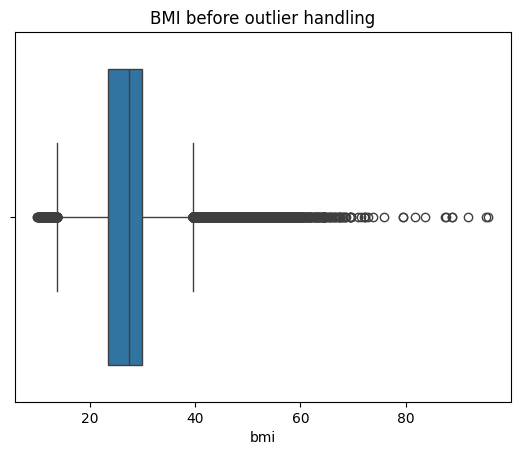

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x=data['bmi'])
plt.title('BMI before outlier handling')

In [15]:
import numpy as np
from scipy.stats import zscore

# Calculate z-scores
z_scores = zscore(data['bmi'])

# Identify outliers (|z| > 2)
data = data[np.abs(z_scores) <= 4]
data.shape

(95800, 9)

Text(0.5, 1.0, 'BMI after outlier handling')

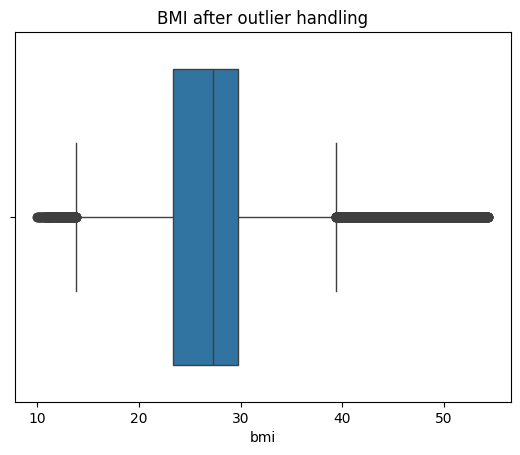

In [16]:
sns.boxplot(x=data['bmi'])
plt.title('BMI after outlier handling')


In [17]:
data.describe()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
count,95800.000000,95800.000000,95800.000000,95800.000000,95800.000000,95800.000000,95800.000000,95800.000000,95800.000000
mean,0.416493,41.783353,0.077192,0.040814,1.376159,27.203113,5.531217,138.159802,0.087328
std,0.493361,22.486496,0.266897,0.197861,1.551547,6.474595,1.072285,40.848026,0.282316
min,0.000000,0.080000,0.000000,0.000000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,0.000000,24.000000,0.000000,0.000000,0.000000,23.380000,4.800000,100.000000,0.000000
50%,0.000000,43.000000,0.000000,0.000000,1.000000,27.320000,5.800000,140.000000,0.000000
75%,1.000000,59.000000,0.000000,0.000000,2.000000,29.790000,6.200000,159.000000,0.000000
max,2.000000,80.000000,1.000000,1.000000,5.000000,54.390000,9.000000,300.000000,1.000000


Text(0.5, 1.0, 'Blood Glucose Level before outlier Handling')

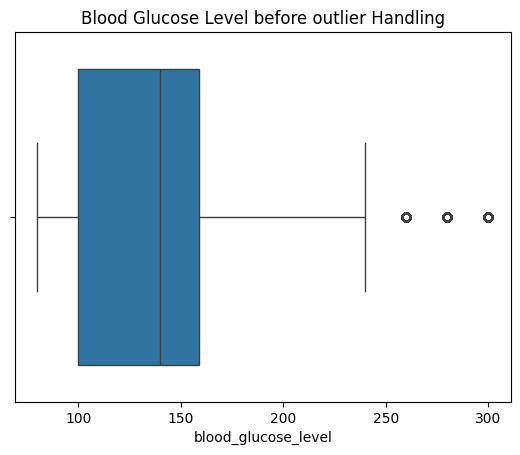

In [18]:
sns.boxplot(x=data['blood_glucose_level'])
plt.title('Blood Glucose Level before outlier Handling')

In [19]:
data= data[data['blood_glucose_level']<240] 

Text(0.5, 1.0, 'Blood Glucose Level after outlier Handling')

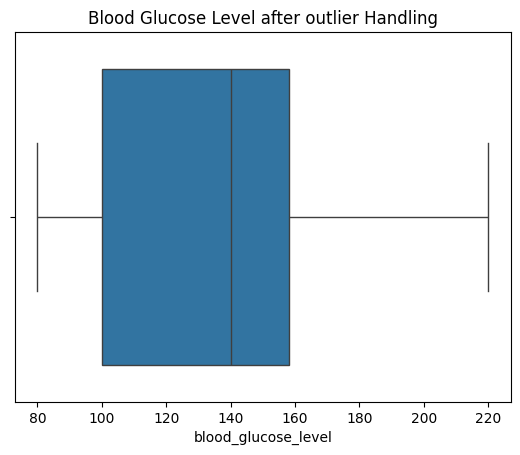

In [20]:
sns.boxplot(x=data['blood_glucose_level'])
plt.title('Blood Glucose Level after outlier Handling')

Text(0.5, 1.0, 'Blood Glucose Level before outlier Handling')

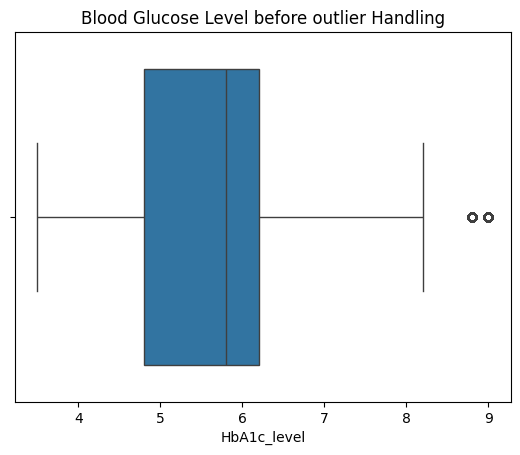

In [21]:
sns.boxplot(x=data['HbA1c_level'])
plt.title('Blood Glucose Level before outlier Handling')

In [22]:
import numpy as np
from scipy.stats import zscore

# Calculate z-scores
z_scores = zscore(data['HbA1c_level'])

# Identify outliers (|z| > 2)
data = data[np.abs(z_scores) <= 3]
data.shape

(92265, 9)

Text(0.5, 1.0, 'Blood Glucose Level after outlier Handling')

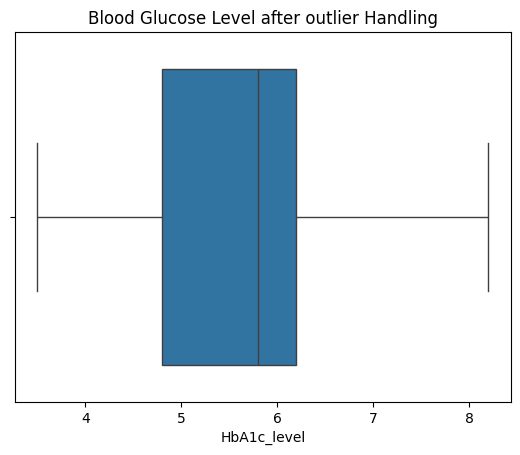

In [23]:
sns.boxplot(x=data['HbA1c_level'])
plt.title('Blood Glucose Level after outlier Handling')

In [24]:
y= data['diabetes']
x= data.drop('diabetes',axis=1)

In [25]:
x

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level
0,0,80.0,0,1,0,25.19,6.6,140
1,0,54.0,0,0,1,27.32,6.6,80
2,1,28.0,0,0,0,27.32,5.7,158
3,0,36.0,0,0,2,23.45,5.0,155
4,1,76.0,1,1,2,20.14,4.8,155
...,...,...,...,...,...,...,...,...
99994,0,36.0,0,0,1,24.60,4.8,145
99996,0,2.0,0,0,1,17.37,6.5,100
99997,1,66.0,0,0,4,27.83,5.7,155
99998,0,24.0,0,0,0,35.42,4.0,100


In [26]:
y

0        0
1        0
2        0
3        0
4        0
        ..
99994    0
99996    0
99997    0
99998    0
99999    0
Name: diabetes, Length: 92265, dtype: int64

In [27]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.2,random_state=42)

In [28]:
from sklearn.linear_model import LogisticRegression
model =LogisticRegression(class_weight='balanced',max_iter=1000)
model.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [29]:
y_pred= model.predict(x_test)

In [30]:
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(18453,))

In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Assuming y_test is true label and y_pred is predicted class
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, model.predict_proba(x_test)[:,1])


In [32]:
accuracy

0.8382918766596218

In [33]:
precision

0.22146739130434784

In [34]:
recall

0.8725910064239829

In [35]:
f1

0.35327264846120504

In [36]:
roc_auc

0.9330099299958576

In [37]:
import pickle

In [38]:
with open("diabetes_prediction_model.pkl",'wb') as f:
    pickle.dump(model,f)